In [3]:
import pandas as pd

In [4]:
df = pd.read_excel("airsen.xlsx", sheet_name="Vols")

In [5]:
df.head()

,ID_Vol,Date_Vol,Heure_Départ,Heure_Arrivée,Aéroport_Départ,Aéroport_Arrivée,Aeroports_Desservis,Distance_km,Durée_vol_min,Numéro_Avion,...,Prénom_Pilote,Sexe,Date_Naissance,Âge_Pilote,Licence_Pilote,Heures_Vol_Pilote,Salaire_Pilote,Statut_Vol,Météo,Nombre_Passagers
0,V0001,18/05/2024,02:15,06:58,Dubaï,Abidjan,Dubaï - Tunis - Abidjan,3614,283,AV646,...,Moussa,Homme,20/09/1987,38,ATPL,3376,8415990,Annulé,Orage,64
1,V0002,15/05/2024,21:00,22:41,Casablanca,Istanbul,Casablanca - Bruxelles - Istanbul,5260,101,AV984,...,Aliou,Homme,29/01/1994,32,ATPL,3116,9326310,Annulé,Orage,169
2,V0003,11/07/2024,07:00,12:38,Bamako,Casablanca,Bamako - Casablanca,6252,338,AV727,...,Cheikh,Homme,02/01/1991,35,ATPL,5498,5034734,Annulé,Vent,266
3,V0004,04/08/2024,23:00,00:38,Abidjan,Bamako,Abidjan - Bamako,6962,98,AV814,...,Ibrahima,Homme,26/05/1989,36,CPL,2649,4361564,Retardé,Nuageux,154
4,V0005,09/02/2024,01:00,03:13,Paris,Dakar,Paris - Abidjan - Bruxelles - Dakar,2767,133,AV612,...,Khadija,Femme,09/07/1992,33,ATPL,11505,2796190,À l’heure,Clair,234


In [ ]:
df.info()

In [ ]:
df.describe()

In [6]:
variable_qualitative = ["Compagnie", "Statut_Vol", "Type_Avion", "Sexe", "Météo"]

In [7]:
# Fonction pour créer tableau de fréquence
def tableau_frequence(data, variable):
    freq = data[variable].value_counts(dropna=False).reset_index()
    freq.columns = ["Libellé", "Effectif"]
    
    freq["Pourcentage"] = round(
        (freq["Effectif"] / freq["Effectif"].sum()) * 100, 2
    )
    
    return freq

In [8]:
# Générer et exporter les tableaux
with pd.ExcelWriter("tableaux_frequences.xlsx") as writer:
    for var in variable_qualitative:
        table = tableau_frequence(df, var)
        print(f"\nTableau de fréquence : {var}")
        print(table)
        
        # Export dans une feuille Excel
        table.to_excel(writer, sheet_name=var[:31], index=False)


Tableau de fréquence : Compagnie
            Libellé  Effectif  Pourcentage
0          Emirates       634        21.13
1       Air Sénégal       622        20.73
2  Turkish Airlines       599        19.97
3   Royal Air Maroc       588        19.60
4        Air France       557        18.57

Tableau de fréquence : Statut_Vol
     Libellé  Effectif  Pourcentage
0     Annulé      1046        34.87
1  À l’heure       990        33.00
2    Retardé       964        32.13

Tableau de fréquence : Type_Avion
       Libellé  Effectif  Pourcentage
0   Boeing 777       529        17.63
1   Boeing 787       513        17.10
2  Airbus A320       504        16.80
3  Airbus A330       489        16.30
4   Boeing 737       484        16.13
5       ATR 72       481        16.03

Tableau de fréquence : Sexe
  Libellé  Effectif  Pourcentage
0   Femme      1522        50.73
1   Homme      1478        49.27

Tableau de fréquence : Météo
      Libellé  Effectif  Pourcentage
0       Orage       535        17

In [8]:
print("Tous les tableaux ont été exportés dans tableaux_frequences.xlsx")

Tous les tableaux ont été exportés dans tableaux_frequences.xlsx


In [1]:
import matplotlib.pyplot as plt

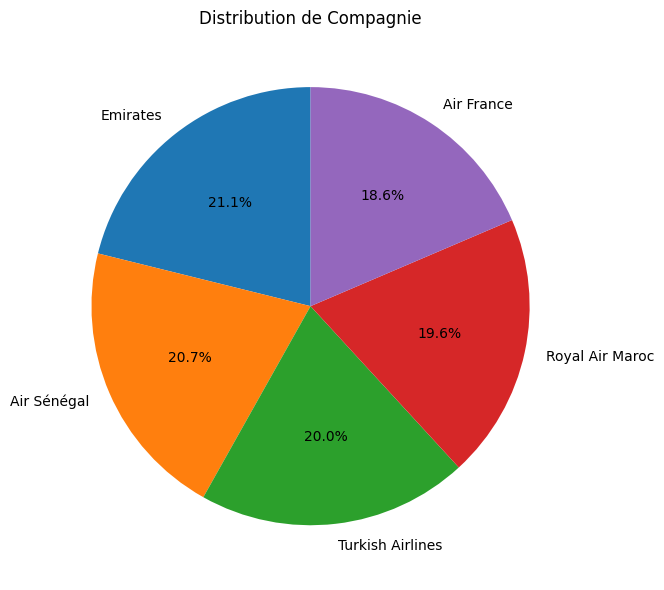

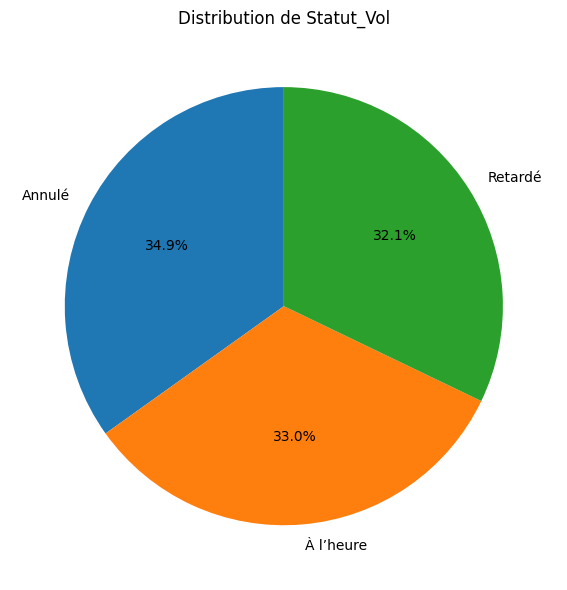

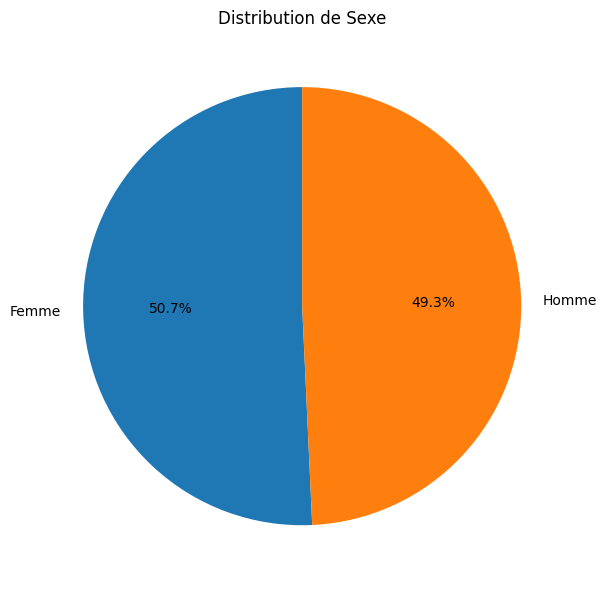

In [15]:
# Create pie charts for qualitative variables with at least 5 categories
for var in variable_qualitative:
    table = tableau_frequence(df, var)
    
    # Only create pie chart if there are at least 5 categories
    if len(table) <= 5:
        plt.figure(figsize=(10, 6))
        plt.pie(table["Pourcentage"], labels=table["Libellé"], autopct="%1.1f%%", startangle=90)
        plt.title(f"Distribution de {var}")
        plt.tight_layout()
        plt.show()

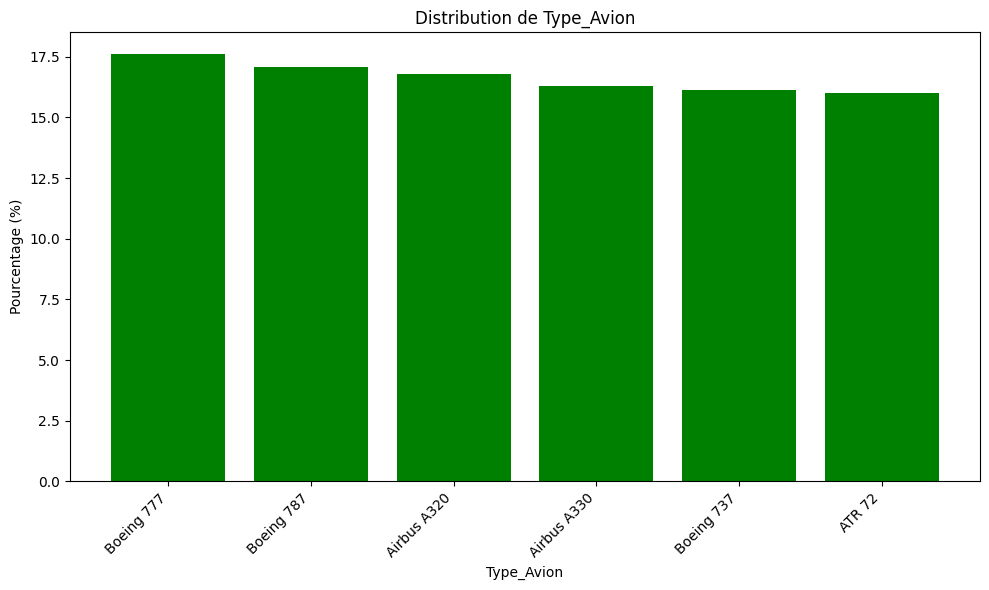

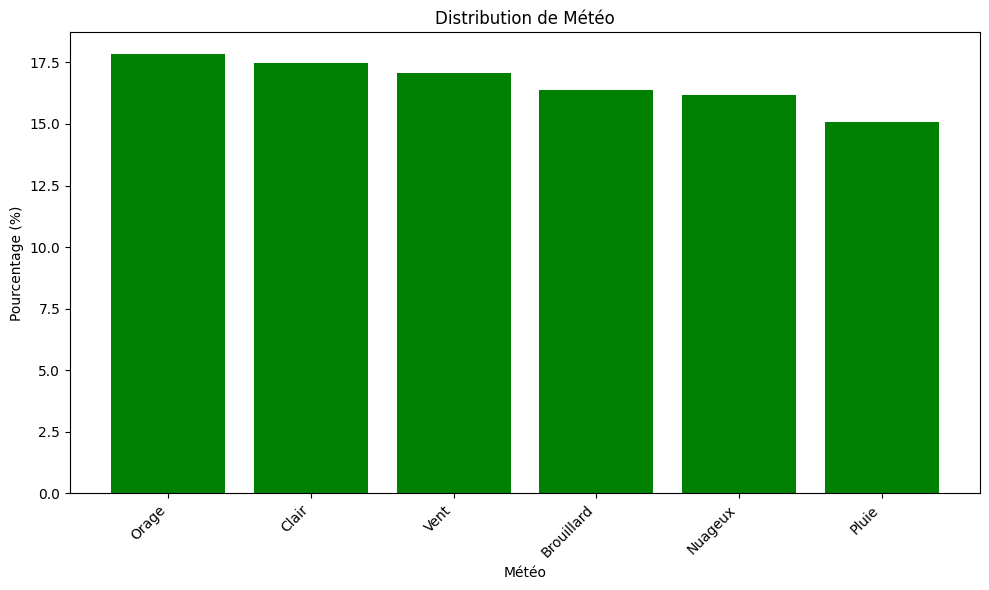

In [19]:
# Histograms of percentages for qualitative variables with at least 6 categories
for var in variable_qualitative:
    table = tableau_frequence(df, var)
    
    # Only create histogram if there are at least 6 categories
    if len(table) > 5:
        plt.figure(figsize=(10, 6))
        plt.bar(table["Libellé"], table["Pourcentage"], color="green")
        plt.xlabel(var)
        plt.ylabel("Pourcentage (%)")
        plt.title(f"Distribution de {var}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()
